<a href="https://colab.research.google.com/github/AndrewLoweUoM/NFM/blob/main/Multiple_Event_Analysis_GAM_Hydrographs__Lags.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Description of Code:

This script performs multi-event hydrological analysis on flow hydrographs, with a focus on:

* Comparing multiple storm events
* Creating a composite (GAM) hydrograph
* Estimating lag time between rainfall and flow
* Quantifying uncertainty (confidence intervals).


This code implements event-based hydrological analysis as follows:

 * Load multi-event rainfall–runoff data
 * Visualise variability across storms
 * Derive a representative (GAM) hydrograph
 * Extract key metrics:
   * Peak flow
   * Peak rainfall
   * Lag time
   * Quantify uncertainty using confidence intervals
   * Export results.

  The script performs multi-event rainfall–runoff analysis and builds a composite hydrograph through statistical smoothing using a Generalized Additive Model (GAM) to estimate peak behaviour, lag time, and uncertainty in rainfall–runoff response.

# Data Loading



In [ ]:
# Load the data using pandas
import pandas as pd # pandas for data manipulation
import matplotlib.pyplot as plt # import the pyplot module from matplotlib
from matplotlib.dates import DateFormatter
import numpy as np # numpy for numerical operations

# Load the event data for all events
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Bollin_storm_event_timeseries_all_events_adjusted.csv'
file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Clipped/Bollin_storm_event_timeseries_all_clipped.csv'
# Load the event data for events before NFM
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Bollin_storm_event_timeseries_all_events_adjusted_before.csv'
# Load the event data for events after NFM
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Bollin_storm_event_timeseries_all_events_adjusted_after.csv.csv'

df_events = pd.read_csv(file_path)
# Displays start data in the Dataframe
df_events.head()

,Time,Event001_Time,Event001_Stage_m,Event001_Flow_m3s,Event001_Rain_mm,Event002_Time,Event002_Stage_m,Event002_Flow_m3s,Event002_Rain_mm,Event003_Time,...,Event049_Flow_m3s,Event049_Rain_mm,Event050_Time,Event050_Stage_m,Event050_Flow_m3s,Event050_Rain_mm,Event051_Time,Event051_Stage_m,Event051_Flow_m3s,Event051_Rain_mm
0,1,03/05/2021 09:00,0.315,2.228,0.10,21/05/2021 07:00,0.443,4.515,0.05,04/07/2021 09:45,...,1.719,0.01,27/09/2025 20:15,0.277,1.773,0.10,03/10/2025 07:00,0.326,2.435,0.01
1,2,03/05/2021 09:15,0.314,2.228,0.05,21/05/2021 07:15,0.443,4.451,0.10,04/07/2021 10:00,...,1.746,0.01,27/09/2025 20:30,0.277,1.787,0.47,03/10/2025 07:15,0.327,2.466,0.00
2,3,03/05/2021 09:30,0.314,2.228,0.00,21/05/2021 07:30,0.442,4.451,0.11,04/07/2021 10:15,...,1.733,0.00,27/09/2025 20:45,0.278,1.760,1.04,03/10/2025 07:30,0.329,2.482,0.00
3,4,03/05/2021 09:45,0.314,2.244,0.00,21/05/2021 07:45,0.440,4.451,0.16,04/07/2021 10:30,...,1.733,0.07,27/09/2025 21:00,0.277,1.760,0.47,03/10/2025 07:45,0.330,2.482,0.00
4,5,03/05/2021 10:00,0.315,2.228,0.11,21/05/2021 08:00,0.439,4.367,0.00,04/07/2021 10:45,...,1.746,0.07,27/09/2025 21:15,0.277,1.828,0.12,03/10/2025 08:00,0.330,2.498,0.00


# Multi-Event Visualisation

### Specify the Number of Events and Specify Time Intervals

In [ ]:
# Number of flood hydrograph events (Event 1 assigned Event ID 0 e.g. for 53 events N = 52 )
N = 52
# Time interval of data
T= 15
# Hourly sub-units
time_units_hour = 60/T

print(f'Number of Events: {N}')
print(f'Time Interval: {T} minutes')
print(f'Time units per hours: {time_units_hour}')

Number of Events: 52
Time Interval: 15 minutes
Time units per hours: 4.0


### Multi Event Hydrograph

Flow plot:

* Loops through all `*_Flow_m3s` columns
* Plots all hydrographs on the same axes

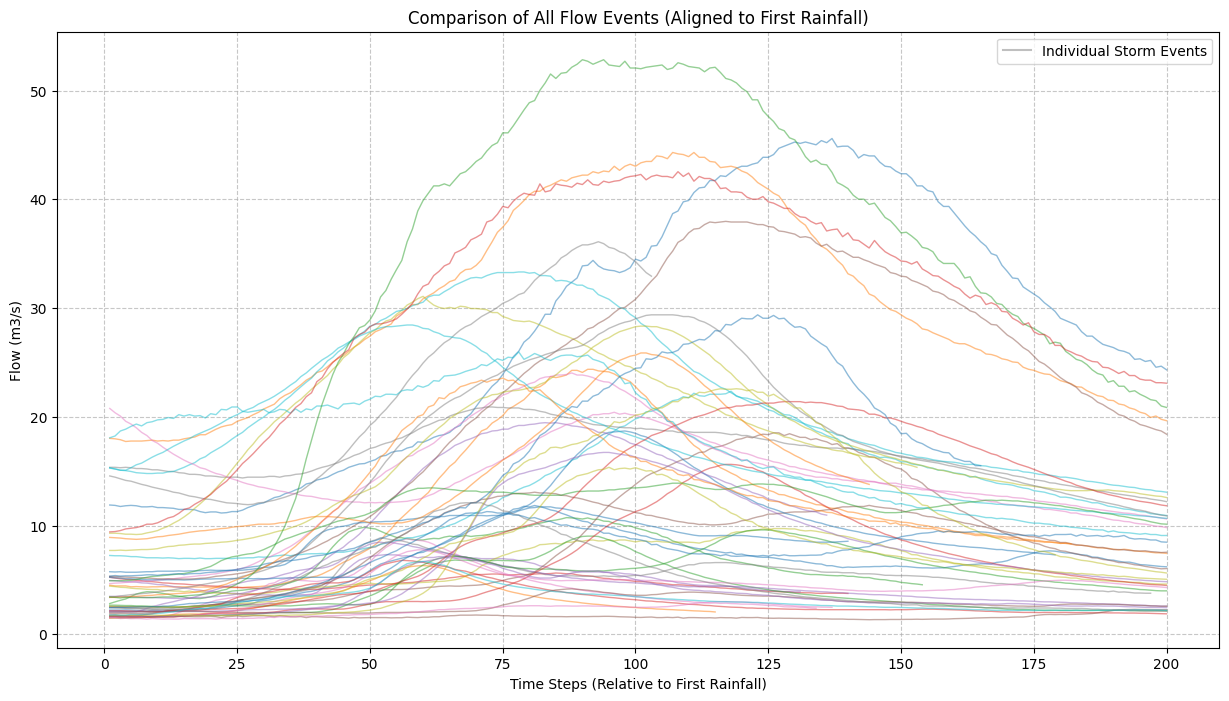

In [ ]:
import matplotlib.pyplot as plt

# Create a figure for the plot
plt.figure(figsize=(15, 8))

# Identify flow columns in the adjusted dataframe
flow_cols = [col for col in df_events.columns if col.endswith('_Flow_m3s')]

# Loop through and plot each event's flow
for col in flow_cols:
    # We plot against the 'Time' column which now represents relative steps from start of rain
    plt.plot(df_events['Time'], df_events[col], alpha=0.5, linewidth=1, label='_nolegend_')

# Add labels and title
plt.xlabel('Time Steps (Relative to First Rainfall)')
plt.ylabel('Flow (m3/s)')
plt.title('Comparison of All Flow Events (Aligned to First Rainfall)')

# Add a grid for readability
plt.grid(True, linestyle='--', alpha=0.7)

# Add a generic legend entry for the events
plt.plot([], [], color='gray', alpha=0.5, label='Individual Storm Events')
plt.legend()

plt.show()

### Multi Event Rainfall Plot

Rainfall plot:

* loops using `*_Rain_mm`
* Uses bar charts to show rainfall pulses


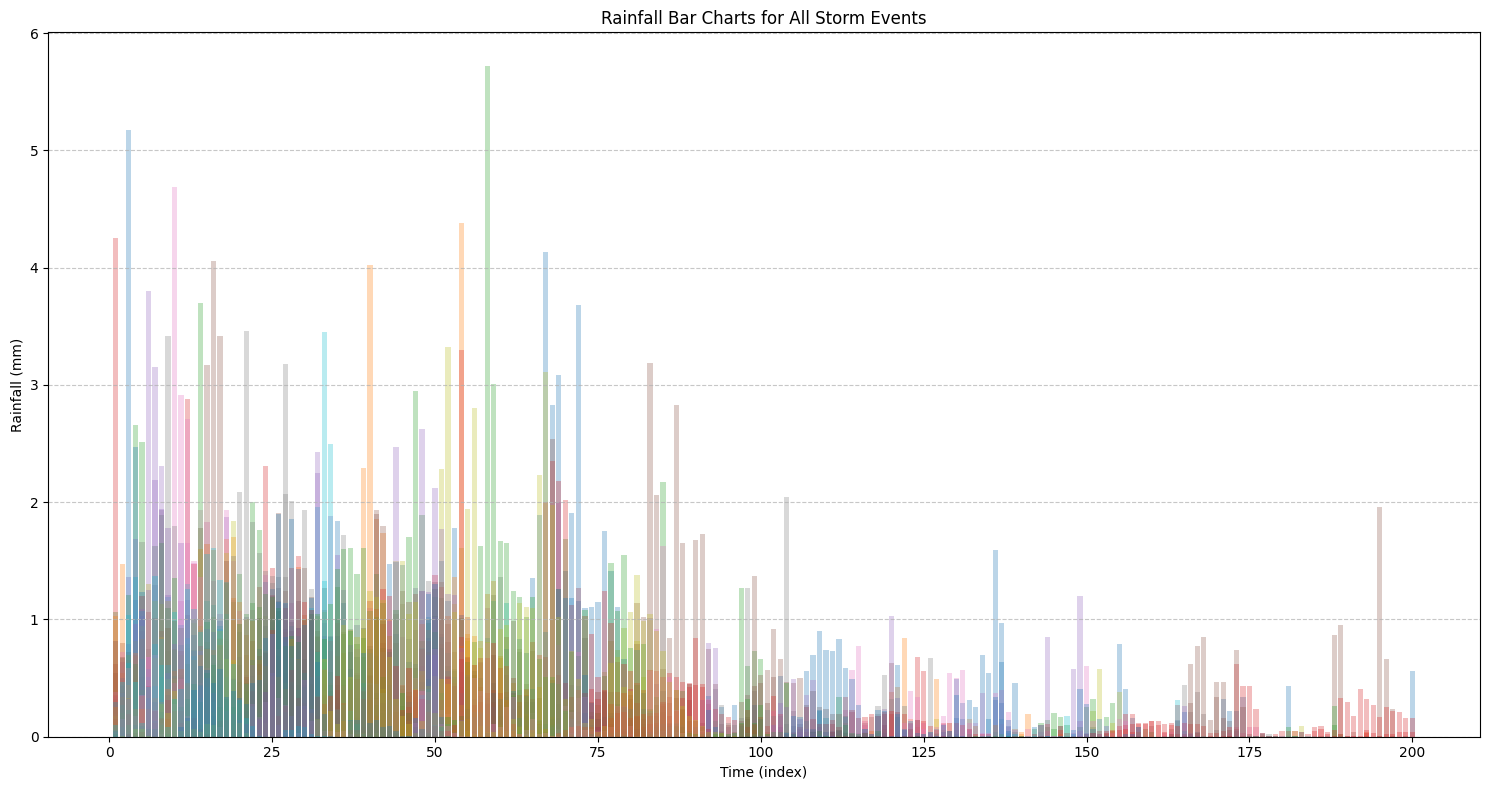

In [ ]:
import matplotlib.pyplot as plt

# Filter for rainfall columns
rain_columns = [col for col in df_events.columns if col.endswith('_Rain_mm')]

# Create a figure
plt.figure(figsize=(15, 8))

# Plot each event's rainfall as a bar chart
for col in rain_columns:
    plt.bar(df_events['Time'], df_events[col], alpha=0.3, label='_nolegend_')

plt.title('Rainfall Bar Charts for All Storm Events')
plt.xlabel('Time (index)')
plt.ylabel('Rainfall (mm)')
#plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# GAM (Generalized Additive Model) Approach

Peak Flow and Rainfall Values, Timing and Lag from GAM Profiles.

### Install pyGAM

Install the pyGAM library and fit a Generalized Additive Model to the long-format flow data using a spline term for the 'Time' variable.


In [ ]:
!pip install pygam

# Fit GAM Models

Two separate models:

* Rainfall GAM
* Flow GAM

# Fit GAM Model to Rainfall

### Data transformation

* Converts wide → long format using 'melt'()
* Combines all events into:
  * Time
  * Rain

* Required for regression-based modelling

# Prepare Rainfall Data for GAM

Transform the wide-format dataset into a long-format DataFrame suitable for GAM regression by 'melting' all individual event flow columns into a single combining flow variable mapped against the 'Time' index. Then fit a Linear GAM model.


In [ ]:
from pygam import LinearGAM, s
import numpy as np

# Time interval of input data which is 15 minutes
time_interval_min = 15
# Number of splines
n_splines_rain = 8

# Prepare Rainfall data for GAM
rain_cols_to_melt = [col for col in df_events.columns if col.endswith('_Rain_mm')]
df_rain_long = df_events.melt(id_vars=['Time'], value_vars=rain_cols_to_melt, var_name='Event_ID', value_name='Rain_mm')

# Filter out rows with missing values in 'Rain_mm' or 'Time'
df_rain_clean = df_rain_long.dropna(subset=['Time', 'Rain_mm']).copy()

# Reset index and verify the transformation
df_rain_clean.reset_index(drop=True, inplace=True)

print(f'Shape of the long-format DataFrame: {df_rain_clean.shape}')
print('\nFirst 5 rows of the prepared data:')
display(df_rain_clean.head())

# Verify that we have data from various events
print('\nUnique events in the long-format data:', df_rain_clean['Event_ID'].nunique())

# Define x, y
X_rain = df_rain_clean['Time'].values.reshape(-1, 1)
y_rain = df_rain_clean['Rain_mm'].values

# Fit GAM to Rainfall
gam_rain = LinearGAM(s(0, n_splines=n_splines_rain)).fit(X_rain, y_rain)

# Generate smooth grid for predictions
# Use a high-resolution grid for a smooth curve
time_grid = np.linspace(df_rain_clean['Time'].min(), df_rain_clean['Time'].max(), 500).reshape(-1, 1)

# Predict over the same time grid
rain_gam_predictions = gam_rain.predict(time_grid)

# Identify the smoothed Rainfall Peak
gam_rain_peak_idx = rain_gam_predictions.argmax()
gam_rain_peak_time = time_grid[gam_rain_peak_idx][0]
gam_rain_peak_value = rain_gam_predictions.max()

print(f'Smoothed Rainfall Peak (GAM): {gam_rain_peak_value:.3f} mm at Time Index: {gam_rain_peak_time:.2f}')

# Convert GAM Rainfall Peak Time from Time Index to Hours (decimal)
gam_rain_peak_time_hours = (gam_rain_peak_time * time_interval_min) / 60
print(f'Smoothed Rainfall Peak (GAM): {gam_rain_peak_value:.3f} mm at Time: {gam_rain_peak_time_hours:.2f} hours (from start)')

# Convert GAM Rainfall Peak Time from Time Index to Hours and Minutes
total_peak_minutes = gam_rain_peak_time * time_interval_min
gam_rain_peak_hours = int(total_peak_minutes // 60)
gam_rain_peak_minutes = int(total_peak_minutes % 60)

print(f'Smoothed Rainfall Peak (GAM): {gam_rain_peak_value:.3f} mm at Time: {gam_rain_peak_hours} hours and {gam_rain_peak_minutes} minutes (from start)')

Shape of the long-format DataFrame: (9410, 3)

First 5 rows of the prepared data:


,Time,Event_ID,Rain_mm
0,1,Event001_Rain_mm,0.10
1,2,Event001_Rain_mm,0.05
2,3,Event001_Rain_mm,0.00
3,4,Event001_Rain_mm,0.00
4,5,Event001_Rain_mm,0.11



Unique events in the long-format data: 51
Smoothed Rainfall Peak (GAM): 0.344 mm at Time Index: 13.76
Smoothed Rainfall Peak (GAM): 0.344 mm at Time: 3.44 hours (from start)
Smoothed Rainfall Peak (GAM): 0.344 mm at Time: 3 hours and 26 minutes (from start)


In [ ]:
# Print model summary
print("GAM Model Summary:")
gam_rain.summary()

GAM Model Summary:
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      6.9941
Link Function:                     IdentityLink Log Likelihood:                                 -3322.8037
Number of Samples:                         9410 AIC:                                             6661.5957
                                                AICc:                                            6661.6109
                                                GCV:                                                0.1189
                                                Scale:                                              0.3446
                                                Pseudo R-Squared:                                    0.117
Feature Function  

/tmp/ipykernel_815/3182134243.py:3: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_rain.summary()


# Model Tuning

* Tests multiple spline counts
* Uses:
  * AIC (model fit)
  * Pseudo R²

#### Display smoothing parameter lambda

In [ ]:
# Display the smoothing parameters (lambda) used in the final model
if 'gam_rain' in globals():
    print(f"Lambda (smoothing penalty) used: {gam_rain.lam}")
else:
    print("Model 'gam' not found in memory. Please ensure the model fitting cell has been run.")

Lambda (smoothing penalty) used: [[0.6]]


#### Optimise the Number of Splines for Rainfall

In [ ]:
from pygam import LinearGAM, s
import numpy as np

# Prepare features (X) and target (y) from existing cleaned data
X = df_rain_clean['Time'].values.reshape(-1, 1)
y = df_rain_clean['Rain_mm'].values

# List of spline counts to test
spline_counts = [5, 8, 10, 15, 20, 25, 30, 50, 100, 150]
aic_results = []

print(f"{'Splines':<10} | {'AIC':<15} | {'Pseudo R2':<10}")
print("-" * 40)

for n in spline_counts:
    # Fit GAM with current spline count
    # Using a fixed lambda (smoothing penalty) for comparison
    model = LinearGAM(s(0, n_splines=n, lam=0.6)).fit(X, y)

    aic = model.statistics_['AIC']
    r2 = model.statistics_['pseudo_r2']['McFadden']

    aic_results.append((n, aic))
    print(f"{n:<10} | {aic:<15.2f} | {r2:<10.4f}")

# Identify the best count
best_n = min(aic_results, key=lambda x: x[1])[0]
print(f"\nOptimal Spline Count (lowest AIC): {best_n}")

Splines    | AIC             | Pseudo R2 
----------------------------------------
5          | 6664.96         | 0.8433    
8          | 6661.60         | 0.8421    
10         | 6660.98         | 0.8416    
15         | 6665.02         | 0.8409    
20         | 6670.35         | 0.8405    
25         | 6673.70         | 0.8398    
30         | 6668.30         | 0.8379    
50         | 6681.49         | 0.8353    
100        | 6730.23         | 0.8320    
150        | 6789.43         | 0.8310    

Optimal Spline Count (lowest AIC): 10


# Fit GAM Model to Flow

### Data transformation

* Converts wide → long format using 'melt'()
* Combines all events into:
  * Time
  * Flow

* Required for regression-based modelling

#### Prepare Flow Data for GAM

Transform the wide-format dataset into a long-format DataFrame suitable for GAM regression by 'melting' all individual event flow columns into a single combining flow variable mapped against the 'Time' index. Then fit a Linear GAM model.


In [ ]:
from pygam import LinearGAM, s
import numpy as np

# Time interval of input data which is 15 minutes
time_interval_min = 15
# Number of splines
n_splines_flow = 9

# Prepare flow data for GAM
flow_cols_to_melt = [col for col in df_events.columns if col.endswith('_Flow_m3s')]
df_flow_long = df_events.melt(id_vars=['Time'], value_vars=flow_cols_to_melt, var_name='Event_ID', value_name='Flow_m3s')

# Filter out rows with missing values in 'Flow_m3m' or 'Time'
df_flow_clean = df_flow_long.dropna(subset=['Time', 'Flow_m3s']).copy()

# Reset index and verify the transformation
df_flow_clean.reset_index(drop=True, inplace=True)

print(f'Shape of the long-format DataFrame: {df_flow_clean.shape}')
print('\nFirst 5 rows of the prepared data:')
display(df_flow_clean.head())

# Verify that we have data from various events
print('\nUnique events in the long-format data:', df_flow_clean['Event_ID'].nunique())

# Define x, y
X_flow = df_flow_clean['Time'].values.reshape(-1, 1)
y_flow = df_flow_clean['Flow_m3s'].values

# Fit GAM to flow
gam_flow = LinearGAM(s(0, n_splines=n_splines_flow)).fit(X_flow, y_flow)

# Generate smooth grid for predictions
# Use a high-resolution grid for a smooth curve
time_grid = np.linspace(df_flow_clean['Time'].min(), df_flow_clean['Time'].max(), 500).reshape(-1, 1)

# Predict over the same time grid
flow_gam_predictions = gam_flow.predict(time_grid)

# Identify the smoothed Flow Peak
gam_flow_peak_idx = flow_gam_predictions.argmax()
gam_flow_peak_time = time_grid[gam_flow_peak_idx][0]
gam_flow_peak_value = flow_gam_predictions.max()

print(f'Smoothed Flow Peak (GAM): {gam_flow_peak_value:.2f} m3s at Time Index: {gam_flow_peak_time:.2f}')

# Convert GAM Flow Peak Time from Time Index to Hours (decimal)
gam_flow_peak_time_hours = (gam_flow_peak_time * time_interval_min) / 60
print(f'Smoothed Flow Peak (GAM): {gam_flow_peak_value:.2f} m3s at Time: {gam_flow_peak_time_hours:.2f} hours (from start)')

# Convert GAM Rainfall Peak Time from Time Index to Hours and Minutes
total_peak_minutes = gam_flow_peak_time * time_interval_min
gam_flow_peak_hours = int(total_peak_minutes // 60)
gam_flow_peak_minutes = int(total_peak_minutes % 60)

print(f'Smoothed Flow Peak (GAM): {gam_flow_peak_value:.2f} m3/s at Time: {gam_flow_peak_hours} hours and {gam_flow_peak_minutes} minutes (from start)')

Shape of the long-format DataFrame: (9410, 3)

First 5 rows of the prepared data:


,Time,Event_ID,Flow_m3s
0,1,Event001_Flow_m3s,2.228
1,2,Event001_Flow_m3s,2.228
2,3,Event001_Flow_m3s,2.228
3,4,Event001_Flow_m3s,2.244
4,5,Event001_Flow_m3s,2.228



Unique events in the long-format data: 51
Smoothed Flow Peak (GAM): 16.12 m3s at Time Index: 97.11
Smoothed Flow Peak (GAM): 16.12 m3s at Time: 24.28 hours (from start)
Smoothed Flow Peak (GAM): 16.12 m3/s at Time: 24 hours and 16 minutes (from start)


In [ ]:
# Print model summary
print("GAM Model Summary:")
gam_flow.summary()

GAM Model Summary:
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.8772
Link Function:                     IdentityLink Log Likelihood:                                -34146.0222
Number of Samples:                         9410 AIC:                                            68309.7987
                                                AICc:                                           68309.8174
                                                GCV:                                               83.2508
                                                Scale:                                              9.1173
                                                Pseudo R-Squared:                                   0.1307
Feature Function  

/tmp/ipykernel_815/4294796700.py:3: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_flow.summary()


# Model Tuning

* Tests multiple spline counts
* Uses:
  * AIC (model fit)
  * Pseudo R²

#### Display the smoothing parameters (lambda)

In [ ]:
# Display the smoothing parameters (lambda) used in the final model
if 'gam_flow' in globals():
    print(f"Lambda (smoothing penalty) used: {gam_flow.lam}")
else:
    print("Model 'gam' not found in memory. Please ensure the model fitting cell has been run.")

Lambda (smoothing penalty) used: [[0.6]]


### Optimise the Number of Splines for Flow

In [ ]:
from pygam import LinearGAM, s
import numpy as np

# Prepare features (X) and target (y) from existing cleaned data
X = df_flow_clean['Time'].values.reshape(-1, 1)
y = df_flow_clean['Flow_m3s'].values

# List of spline counts to test
spline_counts = [5, 8, 9, 10, 15, 20, 25, 30, 50, 100, 150]
aic_results = []

print(f"{'Splines':<10} | {'AIC':<15} | {'Pseudo R2':<10}")
print("-" * 40)

for n in spline_counts:
    # Fit GAM with current spline count
    # Using a fixed lambda (smoothing penalty) for comparison
    model = LinearGAM(s(0, n_splines=n, lam=0.6)).fit(X, y)

    aic = model.statistics_['AIC']
    r2 = model.statistics_['pseudo_r2']['McFadden']

    aic_results.append((n, aic))
    print(f"{n:<10} | {aic:<15.2f} | {r2:<10.4f}")

# Identify the best count
best_n = min(aic_results, key=lambda x: x[1])[0]
print(f"\nOptimal Spline Count (lowest AIC): {best_n}")

Splines    | AIC             | Pseudo R2 
----------------------------------------
5          | 68343.31        | 0.9804    
8          | 68308.17        | 0.9797    
9          | 68309.80        | 0.9797    
10         | 68311.10        | 0.9797    
15         | 68319.60        | 0.9797    
20         | 68328.03        | 0.9797    
25         | 68336.78        | 0.9797    
30         | 68345.39        | 0.9797    
50         | 68378.66        | 0.9798    
100        | 68454.88        | 0.9799    
150        | 68524.77        | 0.9799    

Optimal Spline Count (lowest AIC): 8


# GAM Visualisation

Multiple plots:

* Flow GAM vs Rain GAM
* Combined hydrograph
* Hour-based plots
* Overlay with individual events.

### Plot GAM Fitted Flow and Rainfall (Time Index)

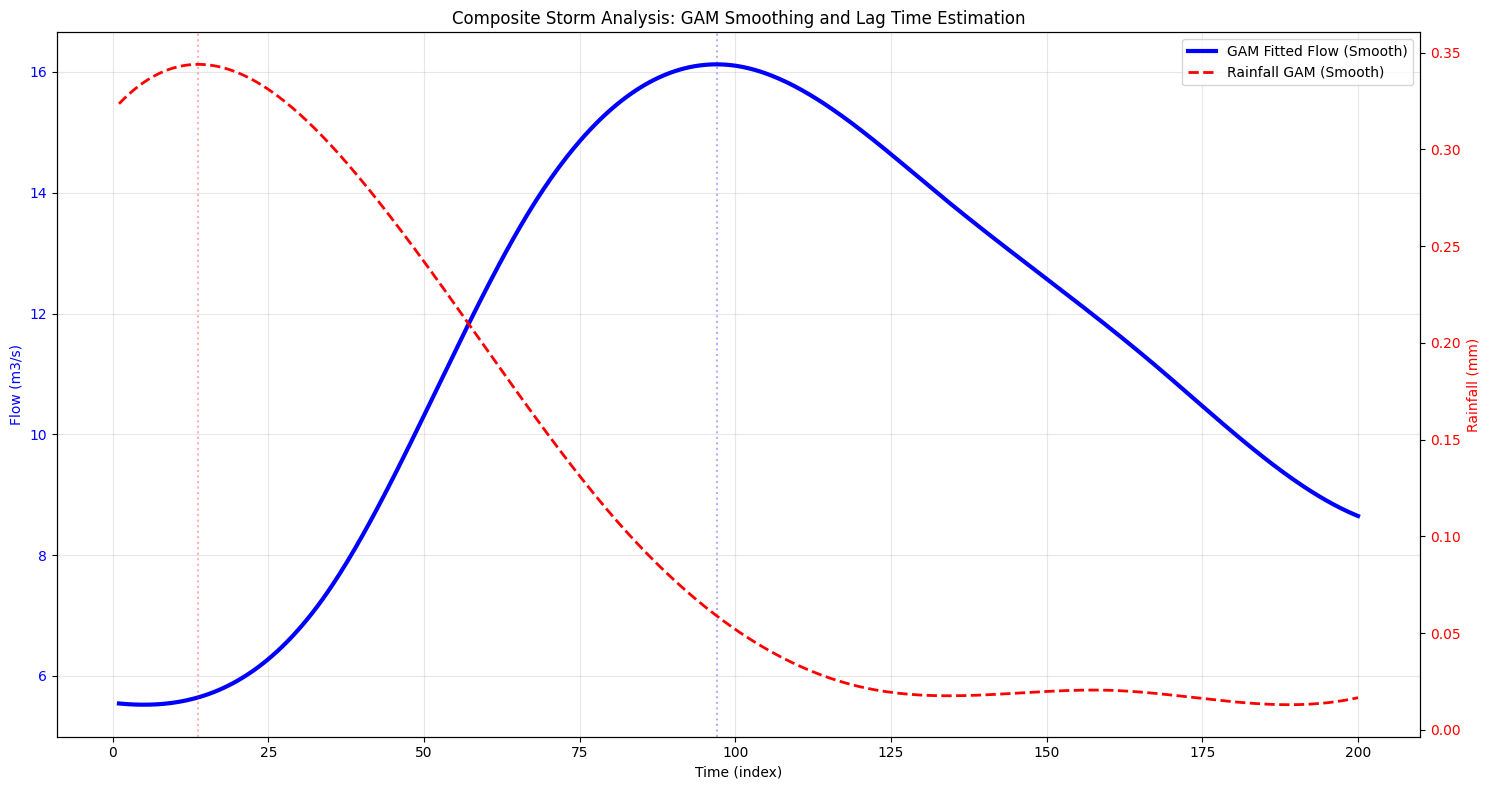

In [ ]:
import matplotlib.pyplot as plt

# Create the figure and subplots
fig, ax1 = plt.subplots(figsize=(15, 8))

# Plot the fitted GAM smooth curve
ax1.plot(time_grid , flow_gam_predictions, color='blue', linewidth=3, label='GAM Fitted Flow (Smooth)')

ax1.set_xlabel('Time (index)')
ax1.set_ylabel('Flow (m3/s)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a single secondary y-axis (ax2) for both rainfall plots
ax2 = ax1.twinx()
ax2.plot(time_grid, rain_gam_predictions, color='red', linewidth=2, linestyle='--', label='Rainfall GAM (Smooth)')
#ax2.bar(df_events_average['Time'], df_events_average['Average_Rain'], color='orange', alpha=0.3, label='Average Rainfall (mm)') # Changed color to avoid confusion with GAM line
ax2.set_ylabel('Rainfall (mm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add markers for both peaks
ax1.axvline(gam_flow_peak_time, color='blue', alpha=0.3, linestyle=':')
ax2.axvline(gam_rain_peak_time, color='red', alpha=0.3, linestyle=':')

# Titles and Legends
plt.title('Composite Storm Analysis: GAM Smoothing and Lag Time Estimation')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# Combine legends from both axes
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Plot GAM Fitted Flow and Rainfall (Time Index)

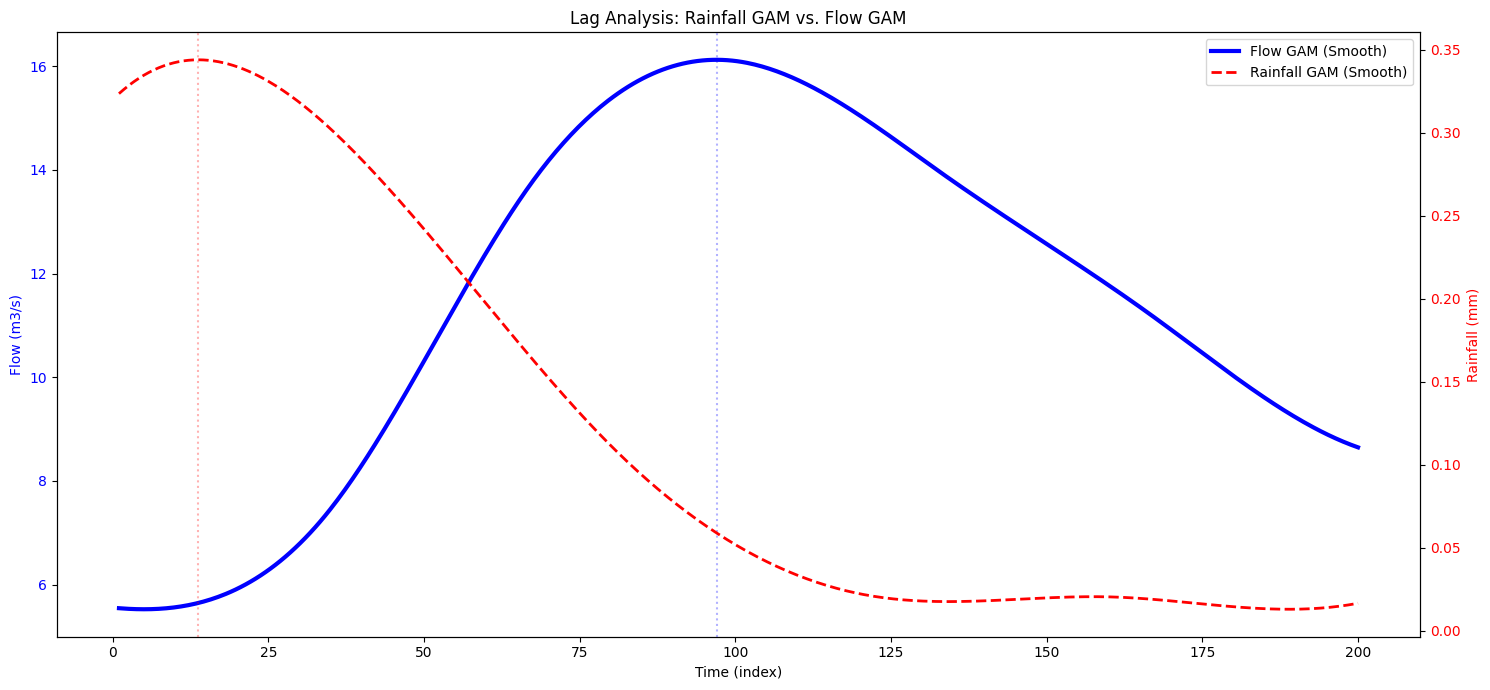

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.set_xlabel('Time (index)')

# Plot Flow GAM
line_flow_gam, = ax1.plot(time_grid, flow_gam_predictions, color='blue', linewidth=3, label='Flow GAM (Smooth)')
ax1.set_ylabel('Flow (m3/s)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot Rainfall GAM on secondary axis
ax2 = ax1.twinx()
line_rain_gam, = ax2.plot(time_grid, rain_gam_predictions, color='red', linewidth=2, linestyle='--', label='Rainfall GAM (Smooth)')
ax2.set_ylabel('Rainfall (mm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add markers for both peaks
ax1.axvline(gam_flow_peak_time, color='blue', alpha=0.3, linestyle=':')
ax2.axvline(gam_rain_peak_time, color='red', alpha=0.3, linestyle=':')


# Titles and Legends
plt.title('Lag Analysis: Rainfall GAM vs. Flow GAM')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# Combine legends from both axes
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

### Plot GAM Fitted Flow and Rainfall (Time Hours)

In [ ]:
print(f'Time units per hour: {time_units_hour}')

# Convert Time Index to hourly by dividing by time interval of 4 (4 units of 15 mins in 1 hour)
x_axis_values = time_grid / time_units_hour
min_x = x_axis_values.min()
max_x = x_axis_values.max()

print(f'Minimum X-axis value: {min_x:.2f} hours')
print(f'Maximum X-axis value: {max_x:.2f} hours')


Time units per hour: 4.0
Minimum X-axis value: 0.25 hours
Maximum X-axis value: 50.00 hours


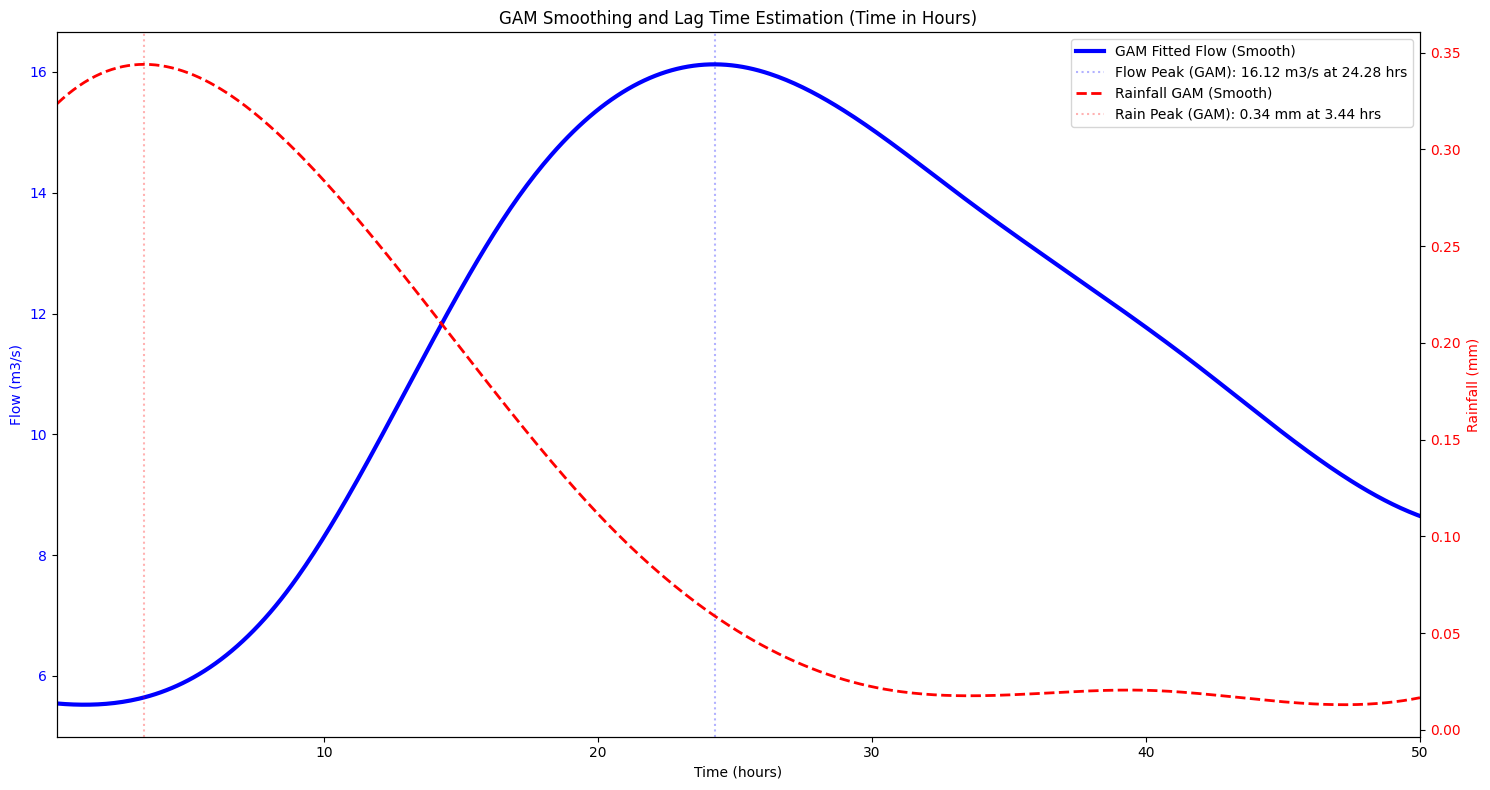

In [ ]:
import matplotlib.pyplot as plt

# Create the figure and subplots
fig, ax1 = plt.subplots(figsize=(15, 8))

# Plot the fitted GAM smooth curve for flow on the primary y-axis
ax1.plot(time_grid / time_units_hour, flow_gam_predictions, color='blue', linewidth=3, label='GAM Fitted Flow (Smooth)')
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Flow (m3/s)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a single secondary y-axis (ax2) for rainfall plots
ax2 = ax1.twinx()
# Plot the fitted GAM smooth curve for rainfall on the secondary y-axis
ax2.plot(time_grid / time_units_hour, rain_gam_predictions, color='red', linewidth=2, linestyle='--', label='Rainfall GAM (Smooth)')

# Plot average rainfall as a bar chart (if desired for comparison)
#ax2.bar(df_events_average['Time'] / time_unit_hour, df_events_average['Average_Rain'], color='orange', alpha=0.3, label='Average Rainfall (mm)')

ax2.set_ylabel('Rainfall (mm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add markers for both peaks, converting time index to hours
ax1.axvline(gam_flow_peak_time / time_units_hour, color='blue', alpha=0.3, linestyle=':', label=f'Flow Peak (GAM): {gam_flow_peak_value:.2f} m3/s at {gam_flow_peak_time_hours:.2f} hrs')
ax2.axvline(gam_rain_peak_time / time_units_hour, color='red', alpha=0.3, linestyle=':', label=f'Rain Peak (GAM): {gam_rain_peak_value:.2f} mm at {gam_rain_peak_time_hours:.2f} hrs')

# Set x-axis limits based on the actual data range
ax1.set_xlim(x_axis_values.min(), x_axis_values.max())

# Titles and Legends
plt.title('GAM Smoothing and Lag Time Estimation (Time in Hours)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# Combine legends from both axes
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

#ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Export of Results



In [ ]:
final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Bollin_GAM_hydrograph.csv'

df_GAM_summary = pd.DataFrame({
    'Time (hours)': (time_grid / time_units_hour).flatten(),
    'Flow_GAM_Predictions': flow_gam_predictions,
    'Rain_GAM_Predictions': rain_gam_predictions
})

# Save the GAM results to new dataframe to CSV
df_GAM_summary.to_csv(final_output_path, index=False)

print(df_GAM_summary.round(2))

print(f'Successfully saved event adjusted results to: {final_output_path}')

     Time (hours)  Flow_GAM_Predictions  Rain_GAM_Predictions
0            0.25                  5.54                  0.32
1            0.35                  5.54                  0.32
2            0.45                  5.54                  0.33
3            0.55                  5.53                  0.33
4            0.65                  5.53                  0.33
..            ...                   ...                   ...
495         49.60                  8.72                  0.02
496         49.70                  8.70                  0.02
497         49.80                  8.68                  0.02
498         49.90                  8.66                  0.02
499         50.00                  8.65                  0.02

[500 rows x 3 columns]
Successfully saved event adjusted results to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Bollin_GAM_hydrograph.csv


# Lag Time Estimation

Definition:
* Lag = time difference between:
  * Peak rainfall (GAM)
  * Peak flow (GAM)

Output:
* Lag in:
  * Hours
  * Hours + minutes

### Calculate GAM Lag Time (Hours)

In [ ]:
# Calculate the difference in Time index
gam_lag_time_hours = gam_flow_peak_time_hours - gam_rain_peak_time_hours

# Print the results to verify
print(f'GAM Lag Time: {gam_lag_time_hours:.2f} hours (from start)')

# Convert average hydrogragh Peak Time to hours an minuties
total_peak_minutes = gam_lag_time_hours * 60
gam_lag_time_hours_hr = int(total_peak_minutes // 60)
gam_lag_time_minutes = int(total_peak_minutes % 60)

print(f'GAM Lag Time: {gam_lag_time_hours_hr} hours and {gam_lag_time_minutes} minutes (from start)')

GAM Lag Time: 20.84 hours (from start)
GAM Lag Time: 20 hours and 50 minutes (from start)


### Create Dictionary of GAM Metrics and Export Results

In [ ]:
# Create a new DataFrame to store result values
GAM_summary_data = {

    'GAM Flow Peak (m3/s)': [gam_flow_peak_value],
    'Time of GAM Peak Flow (hours)': [gam_flow_peak_time ],
    'GAM Rainfall Peak (mm)': [gam_rain_peak_value],
    'Time of GAM Rainfall Peak (hours)': [gam_rain_peak_time ],
    'GAM Lag Time (hours)': [gam_lag_time_hours]


}
GAM_summary_df = pd.DataFrame(GAM_summary_data)

# Round numerical columns for better display
GAM_summary_df = GAM_summary_df.round({
    'GAM Flow Peak (m3/s)': 2,
    'Time of GAM Peak Flow (hours)': 2,
    'GAM Rainfall Peak (mm)': 2,
    'Time of GAM Rainfall Peak (hours)': 2,
    'GAM Lag Time (hours)': 2,

})

# Display the summary DataFrame
pd.set_option('display.width', 500)
display(GAM_summary_df)


# Define the final output file path for the complete event analysis
final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events_LinearGAM.csv'
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events_before_LinearGAM.csv'
# final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events_after_LinearGAM.csv'

# Save the mean_summary_df to CSV
GAM_summary_df.to_csv(final_output_path, index=False)

print(f'Successfully saved event analysis results to: {final_output_path}')

display(gam_lag_time_hours)


,GAM Flow Peak (m3/s),Time of GAM Peak Flow (hours),GAM Rainfall Peak (mm),Time of GAM Rainfall Peak (hours),GAM Lag Time (hours)
0,16.12,97.11,0.34,13.76,20.84


Successfully saved event analysis results to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events_LinearGAM.csv


np.float64(20.837174348697395)

# Comparison: Individual vs GAM Smooth Hydrograph

Plot:
* All individual events (thin blue lines)
* GAM smooth hydrograph (thick black line)

#### Plot All Events with GAM Profile

Create a figure plotting all individual event flow series as thin lines and overlay the GAM hydrograph as a thick black line.


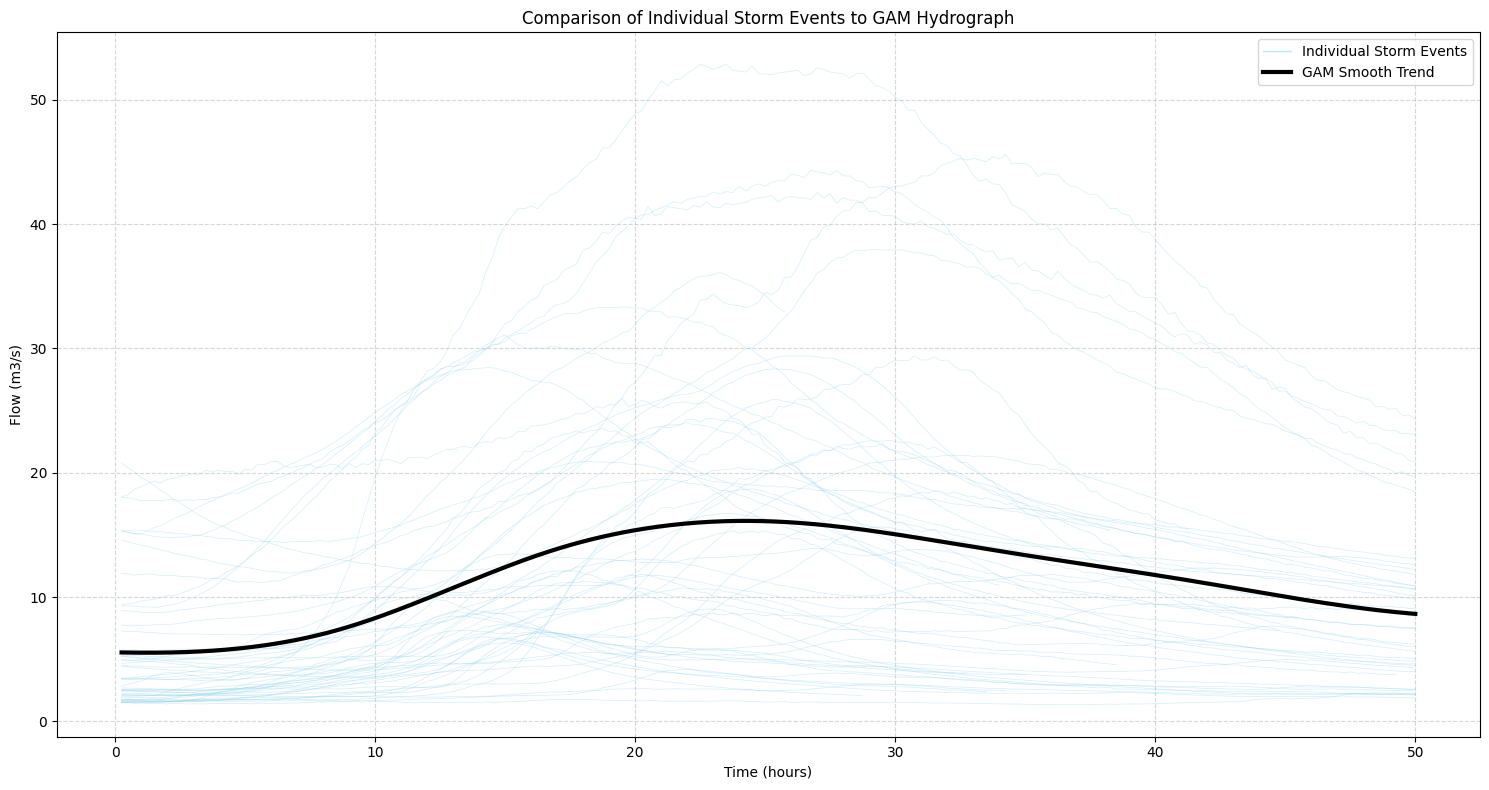

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with specified size
fig, ax = plt.subplots(figsize=(15, 8))

# Plot all individual event series
# flow_columns was identified in previous steps
for col in flow_cols:
    ax.plot(df_events['Time']/4, df_events[col], color='skyblue', linewidth=0.5, alpha=0.35, label='_nolegend_')

# Add a dummy line for the legend to represent individual events
ax.plot([], [], color='skyblue', linewidth=1, alpha=0.5, label='Individual Storm Events')

# Plot the thick GAM smooth curve
ax.plot(time_grid/4, flow_gam_predictions, color='black', linewidth=3, label='GAM Smooth Trend')

# Set axis labels
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Flow (m3/s)')

# Add title
ax.set_title('Comparison of Individual Storm Events to GAM Hydrograph')

# Add legend and grid, then show plot
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Uncertainty Analysis (95% Confidence Interval)

The Generalized Additive Model (GAM) confidence interval in pyGAM is calculated using the model.confidence_intervals() method. This method determines the uncertainty around the fitted smooth function (the GAM trend) by considering the variability in the model's estimated parameters. Unlike simple parametric confidence intervals (e.g., mean ± 1.96 * SEM), the GAM confidence interval accounts for the non-linear nature of the smooth terms, providing a band within which the true mean of the response is expected to lie, given the model.

#### Calculate GAM Confidence Intervals

Compute the 95% confidence intervals for the fitted GAM predictions across the time grid using the model's prediction intervals functionality.


In [ ]:
# Calculate 95% prediction intervals for the GAM model
# width=0.95 corresponds to the 95% confidence interval
gam_ci = gam_flow.confidence_intervals(time_grid, width=0.95)

# Extract lower and upper bounds
gam_ci_low = gam_ci[:, 0]
gam_ci_high = gam_ci[:, 1]

# Print first few values to verify
print('Verification of GAM 95% Confidence Intervals:')
for i in range(5):
    print(f'Time: {time_grid[i][0]:.2f} | Low: {gam_ci_low[i]:.4f} | Prediction: {flow_gam_predictions[i]:.4f} | High: {gam_ci_high[i]:.4f}')

# Check shape consistency
print(f'\nShape of CI array: {gam_ci.shape}')

Verification of GAM 95% Confidence Intervals:
Time: 1.00 | Low: 4.5399 | Prediction: 5.5435 | High: 6.5471
Time: 1.40 | Low: 4.5735 | Prediction: 5.5398 | High: 6.5062
Time: 1.80 | Low: 4.6057 | Prediction: 5.5365 | High: 6.4673
Time: 2.20 | Low: 4.6364 | Prediction: 5.5335 | High: 6.4307
Time: 2.60 | Low: 4.6657 | Prediction: 5.5309 | High: 6.3961

Shape of CI array: (500, 2)


#### Visualize GAM with CI and Individual Events

Generate a comprehensive hydrograph plotting all individual event series as thin, semi-transparent lines, the thick GAM smooth curve, and a shaded region representing the GAM's 95% confidence interval.


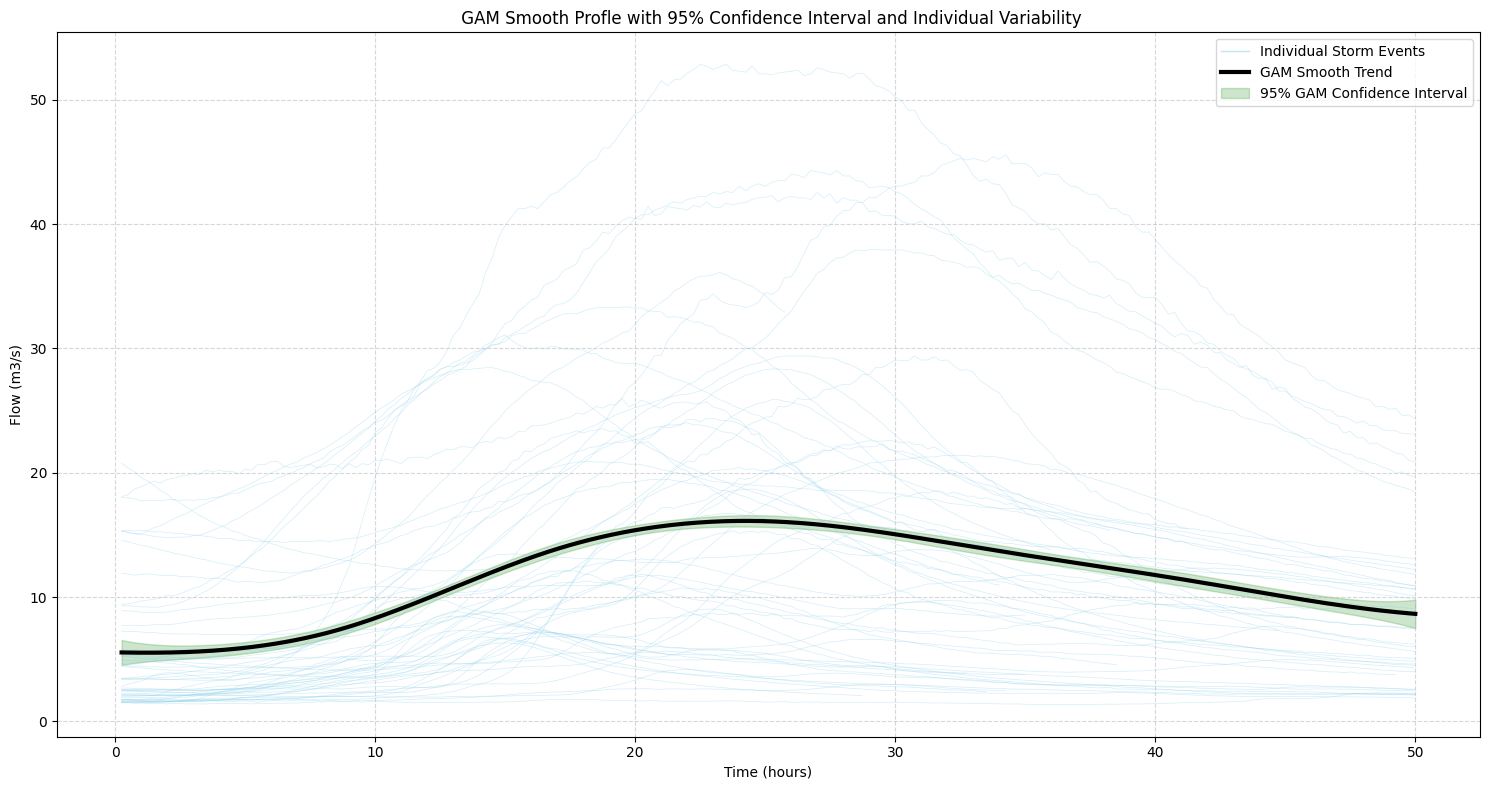

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with specified size
fig, ax = plt.subplots(figsize=(15, 8))

# Plot all individual event series
# flow_columns was identified in previous steps
for col in flow_cols:
    ax.plot(df_events['Time'] / 4, df_events[col], color='skyblue', linewidth=0.5, alpha=0.35, label='_nolegend_')

# Add a dummy line for the legend to represent individual events
ax.plot([], [], color='skyblue', linewidth=1, alpha=0.5, label='Individual Storm Events')

# Plot the thick GAM smooth curve
ax.plot(time_grid / 4, flow_gam_predictions, color='black', linewidth=3, label='GAM Smooth Trend')

# Add shaded region for the 95% Confidence Interval
ax.fill_between(time_grid.flatten() / 4, gam_ci_low, gam_ci_high, color='green', alpha=0.2, label='95% GAM Confidence Interval')

# Set axis labels
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Flow (m3/s)')

# Add title
ax.set_title(' GAM Smooth Profle with 95% Confidence Interval and Individual Variability')

# Add legend and grid, then show plot
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

* GAM Smooth Trend (thick black line): The generalized additive model's best fit for the average flow over time.

* 95% GAM Confidence Interval (shaded green area): This represents the range within which we are 95% confident the true mean of the flow lies, based on the GAM.